In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
import sys
from tqdm import tqdm 
sys.path.append('/home/cosweeney/code/Fits/')

from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck13')
a = 0.83760
redshift=1/a-1
H = cosmo.Hz(redshift)
h = cosmo.h
print(cosmo.h, cosmo.Hz(redshift), cosmo.H0*cosmo.Ez(redshift)) 

sys.path.append('/home/cosweeney/code/clive_bias')
sys.path.append('/home/cosweeney/code/GaussianStreamingModel')


from clive.models import *

import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})

from scipy.stats import gennorm, norm, t
import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import curve_fit

import pandas as pd
import os

plt.rcParams['axes.labelsize'] = 20

from sm_utils import *

from astropy.cosmology import Planck13

print(Planck13)
print(cosmo)

%load_ext autoreload
%autoreload 2

0.6777 74.71913613009617 74.71913613009617
FlatLambdaCDM(name="Planck13", H0=67.77 km / (Mpc s), Om0=0.30712, Tcmb0=2.7255 K, Neff=3.046, m_nu=[0.   0.   0.06] eV, Ob0=0.048252)
Cosmology "planck13" 
    flat = True, Om0 = 0.3071, Ode0 = 0.6928, Ob0 = 0.0483, H0 = 67.77, sigma8 = 0.8288, ns = 0.9611
    de_model = lambda, relspecies = True, Tcmb0 = 2.7255, Neff = 3.0460, powerlaw = False


In [ ]:
# benchmark
import time

#s, mu bins
mu_bins = np.linspace(0,1,120)
rbins = np.linspace(0.001, 80, 60)
rbins_c = 0.5*(rbins[1:] + rbins[:-1])


# path to MDPL2 halos, galaxies, data
halo_path = '/spiff/cosweeney/simulations/MDPL2/hlists/hlist_0.83760_update.hdf5'
hsb_path = '/spiffball/cosweeney/simulations/MDPL2/halos/SBp/'

gal_path = '/spiff/cosweeney/simulations/MDPL2/galaxies/UM_full_gal_table.hdf5'
save_path = '/spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/xi_hg_150.hdf5'

# sim quantities
L_box = 1_000 # h^-1 Mpc
g_box = L_box // 4 # grid size

with h5.File(halo_path, 'r') as hdf:
    hm_cut = hdf['mvir'][()] >= 8e13 # halo mass, h^-1 M_sun

    hpos = np.array([
        hdf['x'][()][hm_cut],
        hdf['y'][()][hm_cut], 
        hdf['z'][()][hm_cut],
    ], dtype=np.float64).T 

    hvel = np.array([
        hdf['vx'][()][hm_cut],
        hdf['vy'][()][hm_cut], 
        hdf['vz'][()][hm_cut],
    ], dtype=np.float64).T 

    with h5.File(gal_path, 'r') as gcat:

        sm_cut = gcat['sm'][()] > 1e10

        gpos = np.array([
            gcat['pos'][:, 0][()][sm_cut],
            gcat['pos'][:, 1][()][sm_cut],
            gcat['pos'][:, 2][()][sm_cut],
        ], dtype=np.float64).T

        gvel = np.array([
            gcat['pos'][:, 3][()][sm_cut],
            gcat['pos'][:, 4][()][sm_cut], 
            gcat['pos'][:, 5][()][sm_cut],
        ], dtype=np.float64).T

        frac = 0.2
        idx = np.random.choice(len(hpos), int(frac * len(hpos)), replace=False)

        t0 = time.perf_counter()
        s_mu_tpcf = compute_tpcf_s_mu(
            s=rbins, 
            mu=mu_bins, 
            pos=hpos[idx], 
            vel=hvel[idx], 
            los_direction=2, 
            redshift=redshift,
            cosmology=Planck13, 
            boxsize=L_box,
            num_threads=84, 
            pos_cross=gpos, 
            vel_cross=gvel,
        )
        t1 = time.perf_counter()

        # Rough upper bound: scales as N^2
        n_full, n_sub = len(hpos), len(idx)
        print(f"Subsample took {t1-t0:.1f}s → full estimate: ~{(t1-t0) * (n_full/n_sub)**2:.0f}s, or {(t1-t0) * (n_full/n_sub)**2 / 3600} hr")

Subsample took 85.4s → full estimate: ~483317732s, or 134254.92555760025 hr


In [7]:
n_full, n_sub = len(hpos), len(idx)
print(f"Subsample took {t1-t0:.1f}s → full estimate: ~{(t1-t0) * (n_full/n_sub)**2:.0f}s, or {(t1-t0) * (n_full/n_sub)**2 / 3600} hr")

Subsample took 85.4s → full estimate: ~2135s, or 0.5930926519070573 hr


In [11]:
# compute RS cg correlation function

#s, mu bins
mu_bins = np.linspace(0,1,120)
rbins = np.linspace(0.5, 150, 120)
rbins_c = 0.5*(rbins[1:] + rbins[:-1])


# path to MDPL2 halos, galaxies, data
halo_path = '/spiff/cosweeney/simulations/MDPL2/hlists/hlist_0.83760_update.hdf5'
hsb_path = '/spiffball/cosweeney/simulations/MDPL2/halos/SBp/'

gal_path = '/spiff/cosweeney/simulations/MDPL2/galaxies/UM_full_gal_table.hdf5'
save_path = '/spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/xi_hg_150.hdf5'

# sim quantities
L_box = 1_000 # h^-1 Mpc
g_box = L_box // 4 # grid size

with h5.File(halo_path, 'r') as hdf:
    hm_cut = hdf['mvir'][()] >= 8e13 # halo mass, h^-1 M_sun

    hpos = np.array([
        hdf['x'][()][hm_cut],
        hdf['y'][()][hm_cut], 
        hdf['z'][()][hm_cut],
    ], dtype=np.float64).T 

    hvel = np.array([
        hdf['vx'][()][hm_cut],
        hdf['vy'][()][hm_cut], 
        hdf['vz'][()][hm_cut],
    ], dtype=np.float64).T 

    with h5.File(gal_path, 'r') as gcat:

        sm_cut = gcat['sm'][()] > 1e10

        gpos = np.array([
            gcat['pos'][:, 0][()][sm_cut],
            gcat['pos'][:, 1][()][sm_cut],
            gcat['pos'][:, 2][()][sm_cut],
        ], dtype=np.float64).T

        gvel = np.array([
            gcat['pos'][:, 3][()][sm_cut],
            gcat['pos'][:, 4][()][sm_cut], 
            gcat['pos'][:, 5][()][sm_cut],
        ], dtype=np.float64).T

        s_mu_tpcf = compute_tpcf_s_mu(
            s=rbins, 
            mu=mu_bins, 
            pos=hpos, 
            vel=hvel, 
            los_direction=2, 
            redshift=redshift,
            cosmology=Planck13, 
            boxsize=L_box,
            num_threads=84, 
            pos_cross=gpos, 
            vel_cross=gvel,
        )

<class 'numpy.ndarray'>
(119, 119)


In [19]:
# save result 

save_path = '/spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/RSCFs/'

with h5.File(save_path+'xi_cg_s_mu_tpcf', 'a') as file:
    file.create_dataset(name='s_mu_tpcf', data=s_mu_tpcf, shape=s_mu_tpcf.shape, dtype=np.float64)
    file.create_dataset(name='sbins', data=rbins, shape=rbins.shape, dtype=np.float64)
    file.create_dataset(name='mu_bins', data=mu_bins, shape=mu_bins.shape, dtype=np.float64)

    file.attrs['redshift'] = redshift


In [16]:
# load result
save_path = '/spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/RSCFs/'


tpcf_file = h5.File(save_path+'xi_cg_s_mu_tpcf', 'r')

s_mu_tpcf = tpcf_file['s_mu_tpcf'][()]

#s, mu bins
mu_bins = tpcf_file['mu_bins'][()]#np.linspace(0,1,120)
rbins = tpcf_file['sbins'][()] #np.linspace(0.5, 150, 120)
rbins_c = 0.5*(rbins[1:] + rbins[:-1])

In [3]:
# load in real-space \xi_cg
xi_path = '/spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/xi_hg_150.hdf5'

hdf = h5.File(xi_path, 'r')

xicg = hdf['xi'][()]
xicg_cov = hdf['xi_cov'][()]

r_cens = hdf['r_cens'][()] 
r_edges = hdf['r_edges'][()] 

# interpolate over same bins
xicg_interp_fcn = interp1d(r_cens, xicg, 'cubic', bounds_error=None, fill_value='extrapolate')
xicg_interp = interp1d(r_cens, xicg, 'cubic', bounds_error=None, fill_value='extrapolate')(rbins_c)

In [18]:
from halotools.mock_observables import tpcf_multipole

monopole = tpcf_multipole(
    s_mu_tpcf, 
    mu_bins, 
    order=0
)
quadrupole = tpcf_multipole(
    s_mu_tpcf, 
    mu_bins, 
    order=2
)
hexadecapole = tpcf_multipole(
    s_mu_tpcf, 
    mu_bins, order=4)

Text(0.5, 1.0, 'MDPL2 True Redshift-space $\\xi_{\\rm cg}(s, \\mu)$')

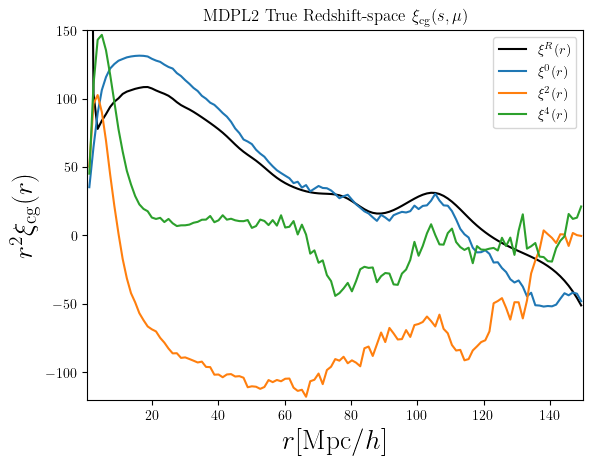

In [21]:

plt.plot(rbins_c, rbins_c**2*xicg_interp,
        label=r'$\xi^R(r)$', c='k')

plt.plot(rbins_c, rbins_c**2*monopole,
        label=r'$\xi^0(r)$')
plt.plot(rbins_c, rbins_c**2*quadrupole,
        label=r'$\xi^2(r)$')
plt.plot(rbins_c, rbins_c**2*hexadecapole,
        label=r'$\xi^4(r)$')
plt.legend()
plt.ylabel(r'$r^2\xi_{\rm cg}(r)$')
plt.xlabel(r'$r [\mathrm{Mpc}/h]$')

plt.xlim((0.5, 150))
plt.ylim((-120,150))
#plt.xscale('log')

plt.title(r'MDPL2 True Redshift-space $\xi_{\rm cg}(s, \mu)$')

In [22]:
from scipy.integrate import quad, simpson

def Pv_R_rlos_scalar(v, R, rlos, M, pars_delta=delta_mpars, pars_sig=rho_pars):
    """
    Elementwise evaluation of P(v | R, rlos, M).
    Accepts arrays of any shape, all broadcast-compatible with each other.
    M is a scalar (fixed mass parameter).
    Returns an array of the same broadcast shape.
    """
    r = np.sqrt(R**2 + rlos**2)
    x = r - R

    mu      = vlos_mean_vec(R, rlos, M)
    sig_v   = sig_vm(x, M, pars_sig)

    sign_rlos = np.where(rlos == 0, 1.0, np.sign(rlos))
    delta_val = Delta(x, M, pars_delta) * sign_rlos

    omega, alpha = skew_interp.get_skew_params(delta_val, sig_v)

    xi = mu + delta_val

    nu  = skew_interp.nu
    z   = (v - xi) / omega
    arg = alpha * z * np.sqrt((nu + 1) / (nu + z**2))
    pdf = (2 / omega) * t.pdf(z, nu) * t.cdf(arg, nu + 1)

    return pdf


def make_los_pdf(M):
    """
    Returns a los_pdf_function(v, R, rlos) compatible with simps_integrate,
    with M fixed.
    """
    def los_pdf(v, R, rlos):
        return Pv_R_rlos_scalar(v, R, rlos, M)
    return los_pdf

def Pv_c(v, R, rlos):

    los_pdf_function = make_los_pdf(M=1e14)#np.median(mbins2)

    return los_pdf_function(v, R, rlos)

def Pv_c_Mpc(v, R, rlos):
    return a*H*Pv_c(v*a*H, R, rlos)

In [23]:
import psutil
psutil.Process().nice(10)

In [25]:
# measure moments with halotools
from halotools.mock_observables import mean_radial_velocity_vs_r, radial_pvd_vs_r

# path to MDPL2 halos, galaxies, data
halo_path = '/spiff/cosweeney/simulations/MDPL2/hlists/hlist_0.83760_update.hdf5'
hsb_path = '/spiffball/cosweeney/simulations/MDPL2/halos/SBp/'

gal_path = '/spiff/cosweeney/simulations/MDPL2/galaxies/UM_full_gal_table.hdf5'
save_path = '/spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/xi_hg_150.hdf5'

# sim quantities
L_box = 1_000 # h^-1 Mpc
g_box = L_box // 4 # grid size

with h5.File(halo_path, 'r') as hdf:
    hm_cut = hdf['mvir'][()] >= 8e13 # halo mass, h^-1 M_sun

    hpos = np.array([
        hdf['x'][()][hm_cut],
        hdf['y'][()][hm_cut], 
        hdf['z'][()][hm_cut],
    ], dtype=np.float64).T 

    hvel = np.array([
        hdf['vx'][()][hm_cut],
        hdf['vy'][()][hm_cut], 
        hdf['vz'][()][hm_cut],
    ], dtype=np.float64).T 

    with h5.File(gal_path, 'r') as gcat:

        sm_cut = gcat['sm'][()] > 1e10

        gpos = np.array([
            gcat['pos'][:, 0][()][sm_cut],
            gcat['pos'][:, 1][()][sm_cut],
            gcat['pos'][:, 2][()][sm_cut],
        ], dtype=np.float64).T

        gvel = np.array([
            gcat['pos'][:, 3][()][sm_cut],
            gcat['pos'][:, 4][()][sm_cut], 
            gcat['pos'][:, 5][()][sm_cut],
        ], dtype=np.float64).T

        v_12 = mean_radial_velocity_vs_r(hpos, hvel,
                                        sample2=gpos, velocities2=gvel, 
                                        rbins_absolute=rbins,
                                        period=L_box,
                                        num_threads=84
                                            )
        v_12 *= (1. + redshift)/100./cosmo.Ez(
            redshift
        )
        # to Mpc/h

        s_12_r = radial_pvd_vs_r(hpos, hvel,
                                sample2=gpos, velocities2=gvel,
                                rbins_absolute=rbins, 
                                period=L_box, 
                                num_threads=84
                                    )   
        s_12_r *= (1. + redshift)/100./cosmo.Ez(
            redshift
        )

        s_12_t_new = tangential_pvd_vs_r(hpos,  # custom function
                                        hvel, 
                                        rbins, 
                                        sample2=gpos, 
                                        velocities2=gvel, 
                                        period=L_box, 
                                        num_threads=84)
        
        s_12_t_new *= (1. + redshift)/100./cosmo.Ez(
            redshift
        )        

        # s_12_t = s_12_r + 1.5 


In [5]:
# compute tangential velocity profile

# path to MDPL2 halos, galaxies, data
halo_path = '/spiff/cosweeney/simulations/MDPL2/hlists/hlist_0.83760_update.hdf5'
hsb_path = '/spiffball/cosweeney/simulations/MDPL2/halos/SBp/'

gal_path = '/spiff/cosweeney/simulations/MDPL2/galaxies/UM_full_gal_table.hdf5'
save_path = '/spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/xi_hg_150.hdf5'

# sim quantities
L_box = 1_000 # h^-1 Mpc
g_box = L_box // 4 # grid size

with h5.File(halo_path, 'r') as hdf:
    hm_cut = hdf['mvir'][()] >= 8e13 # halo mass, h^-1 M_sun

    hpos = np.array([
        hdf['x'][()][hm_cut],
        hdf['y'][()][hm_cut], 
        hdf['z'][()][hm_cut],
    ], dtype=np.float64).T 

    hvel = np.array([
        hdf['vx'][()][hm_cut],
        hdf['vy'][()][hm_cut], 
        hdf['vz'][()][hm_cut],
    ], dtype=np.float64).T 

    with h5.File(gal_path, 'r') as gcat:

        sm_cut = gcat['sm'][()] > 1e10

        gpos = np.array([
            gcat['pos'][:, 0][()][sm_cut],
            gcat['pos'][:, 1][()][sm_cut],
            gcat['pos'][:, 2][()][sm_cut],
        ], dtype=np.float64).T

        gvel = np.array([
            gcat['pos'][:, 3][()][sm_cut],
            gcat['pos'][:, 4][()][sm_cut], 
            gcat['pos'][:, 5][()][sm_cut],
        ], dtype=np.float64).T

        s_12_t_new = tangential_pvd_vs_r(hpos, hvel, rbins, sample2=gpos, velocities2=gvel, period=L_box, num_threads=84)

In [6]:
s_12_t_new.shape

(119,)

In [10]:
rbins_old = np.linspace(0.001, 80, 60)
rbins_c_old = 0.5*(rbins_old[1:] + rbins_old[:-1])

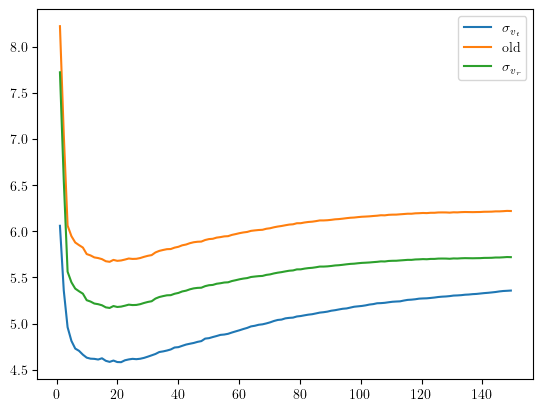

In [38]:
plt.plot(rbins_c, s_12_t_new, label=r'$\sigma_{v_t}$')
plt.plot(rbins_c, s_12_r+0.5, label='old')
plt.plot(rbins_c, s_12_r, label=r'$\sigma_{v_r}$')
plt.legend()

In [39]:
save_path = '/spiffball/cosweeney/simulations/MDPL2/data/GSM_moments_cg_150.hdf5'

with h5.File(save_path, 'w') as f:
    f.create_dataset(name='v_12', data=v_12, shape=v_12.shape, dtype=np.float64)
    f.create_dataset(name='s_12_r', data=s_12_r, shape=s_12_r.shape, dtype=np.float64)
    f.create_dataset(name='s_12_t', data=s_12_t_new, shape=s_12_t_new.shape, dtype=np.float64)

In [ ]:
# load 
save_path = '/spiffball/cosweeney/simulations/MDPL2/data/GSM_moments_cg_150.hdf5'

with h5.File(save_path, 'r') as f:
    v_12 = f['v_12'][()]
    s_12_r = f['s_12_r'][()]
    s_12_t = f['s_12_t'][()]

In [48]:
#from gsm.models.gaussian.from_radial_transverse import moments2gaussian
from scipy.interpolate import UnivariateSpline


gaussian = moments2gaussian(
    m_10=UnivariateSpline(rbins_c, v_12, s=0,ext=3),
    c_20=UnivariateSpline(rbins_c, s_12_t_new, s=0,ext=3),
    c_02=UnivariateSpline(rbins_c, s_12_r, s=0,ext=3)
)

gaussian_s_mu = simps_integrate(
    s_c=rbins_c, mu_c=mu_bins, 
    twopcf_function=UnivariateSpline(rbins_c,
                                     xicg_interp,s=0),
    los_pdf_function=gaussian,
    limit=150, 
    #n=1000
)

gaussian_monopole = tpcf_multipole(
    gaussian_s_mu[:, :-1],
    mu_bins, 
    order=0
)
gaussian_quadrupole = tpcf_multipole(
    gaussian_s_mu[:, :-1], 
    mu_bins, 
    order=2
)
gaussian_hexadecapole = tpcf_multipole(
    gaussian_s_mu[:, :-1], 
    mu_bins, 
    order=4
)

1.2374999999999998 1.2367588673406198


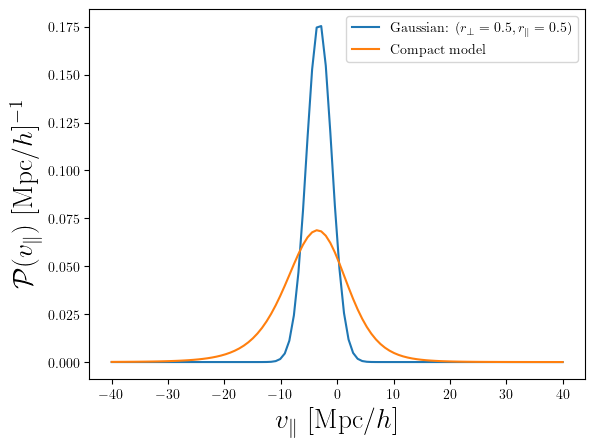

In [49]:
vlos = np.linspace(-40., 40.,100)

R_test = 5
rlos_test = 5

g_test = gaussian(vlos,r_perp=R_test,r_parallel=rlos_test)[0]
c_test = Pv_c_Mpc(vlos, R_test, rlos_test) #a*H*Pv_margM_vec(a*H*vlos, 0.5, 0.5)

plt.plot(vlos, g_test,
        label=r'Gaussian: $(r_\perp = 0.5, r_\parallel = 0.5)$')
plt.plot(vlos, c_test,
        label=r'Compact model')
plt.legend()
plt.ylabel(r'$\mathcal{P}(v_\parallel)$ [Mpc/$h]^{-1}$')
plt.xlabel(r'$v_\parallel$ [Mpc/$h]$')

print(np.sum(g_test), np.sum(c_test))

0.9999999999999968 0.9991066072156944


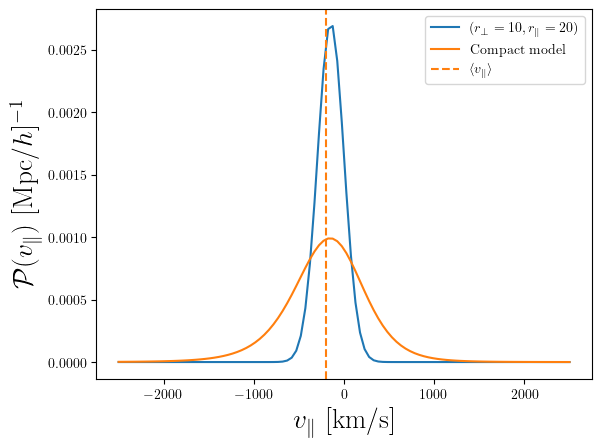

In [13]:
vlos = np.linspace(-2500,2500, 100)

R_test = 10
rlos_test = 20

g_test = (1/a/H)*gaussian(vlos/a/H,r_perp=R_test,r_parallel=rlos_test)[0]
c_test =  Pv_c(vlos, R_test, rlos_test)

plt.plot(vlos, g_test,
        label=rf'$(r_\perp = {R_test}, r_\parallel = {rlos_test})$')
plt.plot(vlos,c_test,
        label=r'Compact model')
plt.axvline(vlos_mean(R_test, rlos_test, 1e14), c='C1', ls='--', label=r'$\langle v_\parallel \rangle$')
plt.legend()
plt.ylabel(r'$\mathcal{P}(v_\parallel)$ [Mpc/$h]^{-1}$')
plt.xlabel(r'$v_\parallel$ [km/s]')

print(np.sum(g_test)*np.diff(vlos)[0], np.sum(c_test)*np.diff(vlos)[0])

In [43]:
from scipy.interpolate import UnivariateSpline

compact_s_mu = simps_integrate(
    s_c=rbins_c, mu_c=mu_bins, 
    twopcf_function=UnivariateSpline(rbins_c,
                                     xicg_interp,s=0),
    los_pdf_function=Pv_c_Mpc,
    limit=150, 

)

compact_monopole = tpcf_multipole(
    compact_s_mu[:, :-1],
    mu_bins, 
    order=0
)
compact_quadrupole = tpcf_multipole(
    compact_s_mu[:, :-1], 
    mu_bins, 
    order=2
)
compact_hexadecapole = tpcf_multipole(
    compact_s_mu[:, :-1], 
    mu_bins, 
    order=4
)

Text(0.5, 0, '$r$ [Mpc/$h$]')

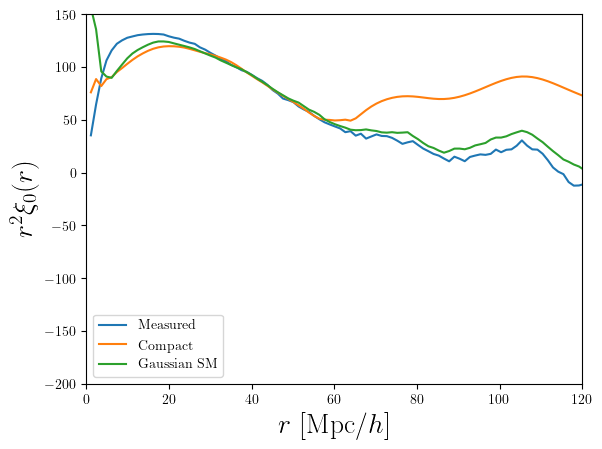

In [50]:
plt.plot(rbins_c, rbins_c**2*monopole,
       label='Measured')
plt.plot(rbins_c, rbins_c**2*compact_monopole,
        label='Compact')
plt.plot(rbins_c, rbins_c**2*gaussian_monopole,
        label='Gaussian SM')
plt.xlim(0,120) # if you want larger scales, extend the integration
# limit on simps integrate + extend UnivariateSpline limits 
# for moments and correlation function, remember it is an integral!
plt.ylim(-200,150)
plt.legend()
plt.ylabel(r'$r^2\xi_0(r)$')
plt.xlabel(r'$r$ [Mpc/$h$]')

Text(0.5, 0, '$r$ [Mpc/$h$]')

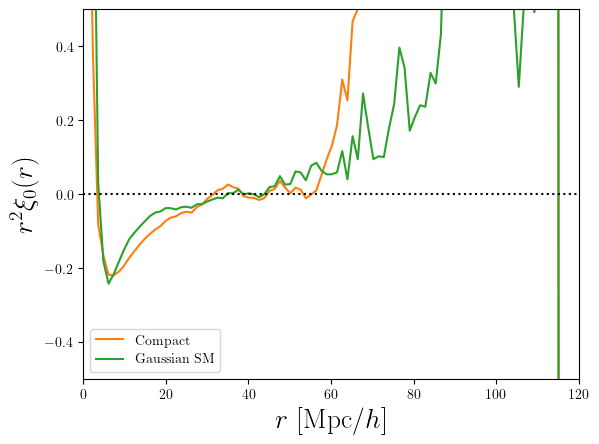

In [46]:
# plt.plot(rbins_c, monopole,
#        label='Measured')
plt.plot(rbins_c, (compact_monopole-monopole)/monopole,
        label='Compact', c='C1')
plt.plot(rbins_c, (gaussian_monopole-monopole)/monopole,
        label='Gaussian SM', c='C2')
plt.xlim(0,120) # if you want larger scales, extend the integration
# limit on simps integrate + extend UnivariateSpline limits 
# for moments and correlation function, remember it is an integral!
plt.ylim(-0.5,0.5)
plt.axhline(0, c='k', ls=':')
plt.legend()
plt.ylabel(r'$r^2\xi_0(r)$')
plt.xlabel(r'$r$ [Mpc/$h$]')

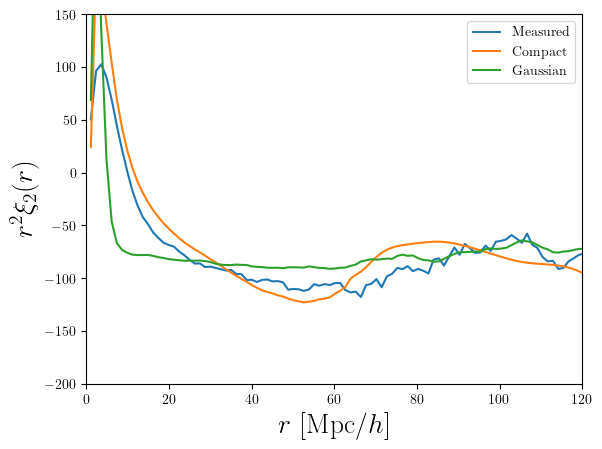

In [45]:
plt.plot(rbins_c, rbins_c**2*quadrupole,
        label='Measured')
plt.plot(rbins_c, rbins_c**2*compact_quadrupole,
        label='Compact')
plt.plot(rbins_c, rbins_c**2*gaussian_quadrupole,
        label='Gaussian')
plt.ylabel(r'$r^2\xi_2(r)$')
plt.xlabel(r'$r$ [Mpc/$h$]')

plt.xlim(0,120)
plt.ylim(-200,150)
plt.legend()

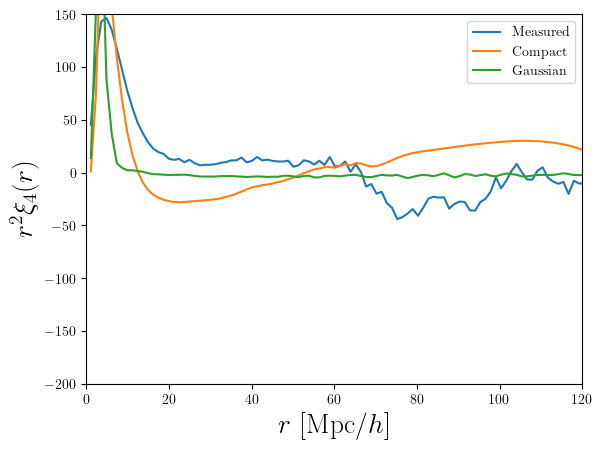

In [47]:
plt.plot(rbins_c, rbins_c**2*hexadecapole,
        label='Measured')
plt.plot(rbins_c, rbins_c**2*compact_hexadecapole,
        label='Compact')
plt.plot(rbins_c, rbins_c**2*gaussian_hexadecapole,
        label='Gaussian')
plt.ylabel(r'$r^2\xi_4(r)$')
plt.xlabel(r'$r$ [Mpc/$h$]')


plt.xlim(0,120)
plt.ylim(-200,150)
plt.legend()

Text(0.5, 1.0, 'MDPL2 True Redshift-space $\\xi_{\\rm cg}(s, \\mu)$')

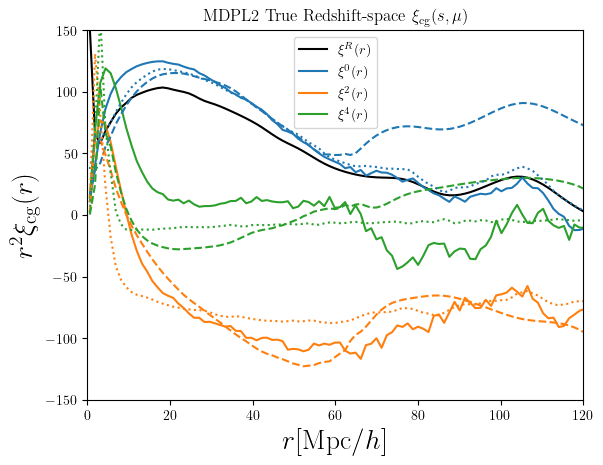

In [30]:

plt.plot(rbins_c, rbins_c**2*xicg_interp,
        label=r'$\xi^R(r)$', c='k')
plt.plot(rbins_c, rbins_c**2*monopole,
        label=r'$\xi^0(r)$')
plt.plot(rbins_c, rbins_c**2*quadrupole,
        label=r'$\xi^2(r)$')
plt.plot(rbins_c, rbins_c**2*hexadecapole,
        label=r'$\xi^4(r)$')

plt.plot(rbins_c, rbins_c**2*compact_monopole,
        ls='--', c='C0')
plt.plot(rbins_c, rbins_c**2*compact_quadrupole,
        ls='--', c='C1')
plt.plot(rbins_c, rbins_c**2*compact_hexadecapole,
        ls='--', c='C2')

plt.plot(rbins_c, rbins_c**2*gaussian_monopole,
        ls=':', c='C0')
plt.plot(rbins_c, rbins_c**2*gaussian_quadrupole,
        ls=':', c='C1')
plt.plot(rbins_c, rbins_c**2*gaussian_hexadecapole,
        ls=':', c='C2')


plt.legend()
plt.ylabel(r'$r^2\xi_{\rm cg}(r)$')
plt.xlabel(r'$r [\mathrm{Mpc}/h]$')

plt.xlim((0, 120))
plt.ylim((-150, 150))

plt.title(r'MDPL2 True Redshift-space $\xi_{\rm cg}(s, \mu)$')